# Chapter 8 — War, Aviation, and the Acceleration of Truth
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 8 — War, Aviation, and the Acceleration of Truth.

The *V–n diagram* is the single most important picture in aviation structures: it draws the exact border between flight and failure. It defines every combination of speed and load factor that the airframe must survive — and the margins that separate the two. Before strain gages, those margins were estimated from theory and confirmed only by pulling a structure to destruction on the ground. After strain gages, they could be measured in flight, in real time, on every maneuver.

The V–n diagram below encodes the full structural commitment of an airframe: the *stall boundary* that limits low-speed maneuvering, the positive and negative *limit load factors* set by the certification basis, and the *dive speed* beyond which structural integrity is no longer guaranteed. Strain gages on wing spars, fuselage frames, and control surfaces turn this abstract envelope into real-time *load factor* data — closing the loop between design assumption and operational reality.

**This notebook demonstrates:**
1. Building the V–n (velocity–load factor) structural envelope for a representative light aircraft — the boundary that strain gage flight testing exists to verify.

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Generated figures are written next to the chapter's other media.
OUT_DIR = Path("../src/media/ch08")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — The V–n Structural Envelope

The V–n diagram is both a design document and an operating limit. It is bounded by three curves: the aerodynamic *stall boundary* (where the wing can no longer generate enough lift), the *structural limit load* (where the airframe would yield or fail), and the *dive speed* limit (beyond which flutter or dynamic pressure exceeds design assumptions). Every point inside the enclosed region is a combination of speed and load factor the aircraft must survive. Every point outside it is a condition the structure was never built for.

The stall boundary follows directly from balancing lift against weight. At the point of stall the wing produces its maximum lift, $L = \tfrac{1}{2}\rho V^2 S\, C_{L,\max}$, and the load factor is that lift divided by the aircraft's weight, $n = L/W$. Solving for the speed at which the wing stalls at a given load factor gives

$$V_s(n) = \sqrt{\dfrac{2\,n\,W}{\rho\,S\,C_{L,\max}}}.$$

In words: the faster you fly, the higher the load factor the wing can reach before it stalls — which is why the stall boundary curves up and to the right until it meets the flat structural limit. Note that the weight $W$ here is already an aerodynamic *force* (in newtons), so it enters directly, with no separate factor of $g$.

The code below builds the positive and negative stall curves from this relation and overlays the limit load factors and the dive speed. The shaded region is the flight envelope. A strain gage on the wing spar reports load factor in real time; crossing the envelope boundary is a structural overload.

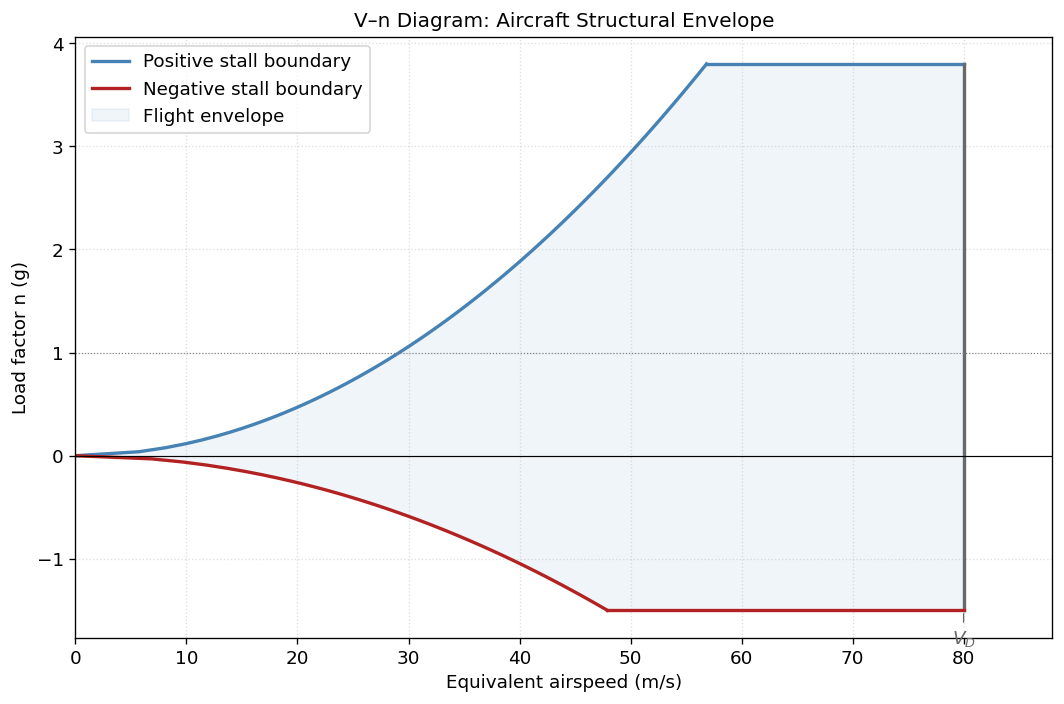

Strain gages on wing spars and fuselage frames measure load factor in flight.
At n = 3.8g the structure experiences 3.8× its own weight in load.
1 g stall speed:        29.2 m/s
Positive corner speed:  56.8 m/s (maneuvering speed V_A, where the stall and limit-load boundaries meet)


In [2]:
# V–n diagram: the aircraft structural envelope.
# Every point inside is a (speed, load factor) combination the airframe must survive.

# --- Aircraft and atmosphere (representative light aircraft) ---
W   = 15000.0   # N       aircraft weight (an aerodynamic force, already in newtons)
S   = 16.0      # m^2     wing reference area
RHO = 1.225     # kg/m^3  air density at sea level
CLMAX_POS = 1.8   # max lift coefficient, upright flight
CLMAX_NEG = 1.0   # max lift coefficient magnitude, inverted flight

# --- Structural limits (from the certification basis) ---
N_LIM_POS =  3.8   # positive limit load factor (g)
N_LIM_NEG = -1.5   # negative limit load factor (g)
V_D       = 80.0   # m/s   design dive speed


def stall_speed(n, clmax, W=W, S=S, rho=RHO):
    """Speed at which the wing stalls at load factor ``n``.

    Balances maximum lift against ``n`` times weight,
        n * W = 0.5 * rho * V**2 * S * clmax,
    and solves for V. ``W`` is a weight (a force in N), so no factor of g
    appears. ``n`` and ``clmax`` are treated as magnitudes.
    """
    return np.sqrt(2.0 * np.abs(n) * W / (rho * S * clmax))


# Positive and negative stall boundaries, sampled in load factor.
n_pos = np.linspace(0.0, N_LIM_POS, 100)
n_neg = np.linspace(N_LIM_NEG, 0.0, 50)
Vs_pos = stall_speed(n_pos, CLMAX_POS)
Vs_neg = stall_speed(n_neg, CLMAX_NEG)
# Vs_neg[0]  = stall speed at N_LIM_NEG (fastest of the negative stall speeds)
# Vs_neg[-1] = 0 (stall speed at n = 0)

fig, ax = plt.subplots(figsize=(9, 6))

# Positive stall boundary + top limit (blue)
ax.plot(Vs_pos, n_pos, color='steelblue', lw=2, label='Positive stall boundary')
ax.plot([Vs_pos[-1], V_D], [N_LIM_POS, N_LIM_POS], color='steelblue', lw=2)

# Dive speed limit (gray vertical)
ax.plot([V_D, V_D], [N_LIM_NEG, N_LIM_POS], color='dimgray', lw=2)

# Negative stall boundary + bottom limit (red)
ax.plot([Vs_neg[0], V_D], [N_LIM_NEG, N_LIM_NEG], color='firebrick', lw=2)
ax.plot(Vs_neg, n_neg, color='firebrick', lw=2, label='Negative stall boundary')

# Shade only the true flight envelope polygon
env_x = list(Vs_pos) + [V_D, V_D, Vs_neg[0]] + list(Vs_neg)
env_y = list(n_pos) + [N_LIM_POS, N_LIM_NEG, N_LIM_NEG] + list(n_neg)
ax.fill(env_x, env_y, alpha=0.08, color='steelblue', label='Flight envelope')

# Annotate V_D on the x-axis
ax.annotate('$V_D$', xy=(V_D, N_LIM_NEG), xytext=(V_D, N_LIM_NEG - 0.18),
            ha='center', va='top', fontsize=11, color='dimgray',
            arrowprops=dict(arrowstyle='-', color='dimgray', lw=0.8))

ax.axhline(0, color='black', lw=0.7)
ax.axhline(1, color='gray', lw=0.7, linestyle=':')  # 1 g, level flight
ax.set_xlabel('Equivalent airspeed (m/s)')
ax.set_ylabel('Load factor n (g)')
ax.set_title('V–n Diagram: Aircraft Structural Envelope')
ax.set_xlim(0, V_D * 1.1)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig08_nb1_aircraft_vn_diagram.png', bbox_inches='tight', dpi=150)
plt.show()

print("Strain gages on wing spars and fuselage frames measure load factor in flight.")
print(f"At n = {N_LIM_POS}g the structure experiences {N_LIM_POS}× its own weight in load.")
print(f"1 g stall speed:       {stall_speed(1.0, CLMAX_POS):5.1f} m/s")
print(f"Positive corner speed: {stall_speed(N_LIM_POS, CLMAX_POS):5.1f} m/s "
      f"(maneuvering speed V_A, where the stall and limit-load boundaries meet)")

---
## Where to take this next

The envelope here is a static design boundary. Strain gage flight testing is what turns it into a measured, living record. A few concrete directions to build on this notebook:

1. **Overlay a measured maneuver.** Simulate (or import) a time history of load factor from a flight — a pull-up, a gust encounter, a rolling pullout — and plot the resulting $(V, n)$ trace on top of the envelope to see how close the maneuver came to a boundary. This is exactly what a flight-test engineer does with wing-spar strain data.
2. **Add the gust envelope.** Overlay the design gust lines (for example the $\pm 25$ and $\pm 50$ ft/s gusts of the certification basis), computing the gust load factor from the aircraft mass ratio and lift-curve slope. On many transport wings the gust case, not the maneuver case, sets the limit load.
3. **Convert load factor to spar strain.** Given a spar cross-section ($I$, extreme-fiber distance $c$, and modulus $E$), map load factor to bending strain and print the microstrain a gage would read at each corner of the envelope — connecting the abstract diagram to the number that actually appears on the bridge.